## **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## **Load Dataset**

In [2]:
df = pd.read_excel("P652-Dataset.xlsx")
df.head(10)

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."
5,Too much lagging and slow,1,I will never purchase Samsung phones. Phone is...
6,Worst samsung mobile ever,1,This is worst samsung mobile I have seen from ...
7,कैसा दिखाते है उसका 10 % भी नही,1,मोबाइल का कैमरा बिल्कुल भी सही नही है 48 PM बत...
8,Slow performance,1,The phone hangs a lot and is very slow. I rece...
9,Don’t buy from Amazon.,1,Very poor quality camera .Found box seal damag...


In [3]:
df.shape

(1440, 3)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1440 non-null   object
 1   rating  1440 non-null   int64 
 2   body    1440 non-null   object
dtypes: int64(1), object(2)
memory usage: 33.9+ KB


In [5]:
df.isnull().sum()

title     0
rating    0
body      0
dtype: int64

In [6]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
rating,1440.0,3.173611,1.584453,1.0,1.0,4.0,5.0,5.0


In [7]:
df.head()

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."


In [8]:
df['combine_text']=df['title'].fillna('') + " " + df['body'].fillna('')

In [9]:
from langdetect import detect

df['language'] = df['combine_text'].apply(lambda x: detect(x))

In [10]:
# remove non english reviews from the dataset
df = df[df['language'] == 'en']

In [11]:
df.head()

,title,rating,body,combine_text,language
0,Horrible product,1,Very disappointed with the overall performance...,Horrible product Very disappointed with the ov...,en
2,Overall,4,"Got the mobile on the launch date,Battery must...","Overall Got the mobile on the launch date,Batt...",en
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....,A big no from me 1. It doesn't work with 5.0GH...,en
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp...",Put your money somewhere else Not worth buying...,en
5,Too much lagging and slow,1,I will never purchase Samsung phones. Phone is...,Too much lagging and slow I will never purchas...,en


## **Feature Engineering**

In [12]:
import re
import string
import emoji

def clean_text(text):
    
    text = text.lower()

    # remove urls
    text = re.sub(r'http\S+|www\S+', '', text)

    # remove hashtags
    text = re.sub(r'#\w+', '', text)

    # remove numbers
    text = re.sub(r'\d+', '', text)

    # replace punctuation with space
    text = re.sub(r'[^\w\s]', ' ', text)

    # keep only words
    text = re.sub(r'[^a-z\s]', ' ', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text    
    

# Combine title and body
df["cleaned_text"] = df["combine_text"].apply(clean_text)

In [13]:
df['text_length'] = (df["cleaned_text"]).apply(lambda x: len(str(x)))

In [14]:
df['cleaned_text'].shape

(1411,)

## **EDA (Exploratory Data Analysis)**

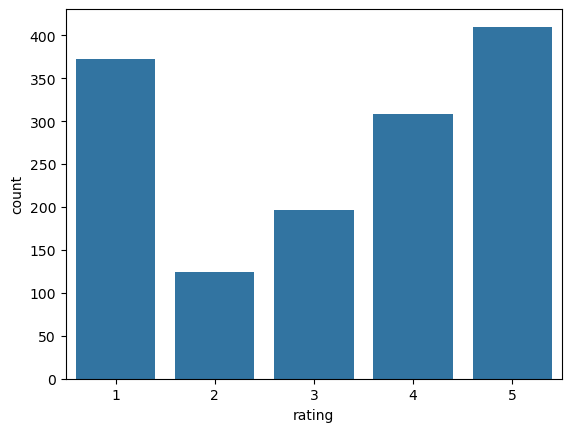

In [15]:
sns.countplot(x = 'rating', data = df)
plt.show()

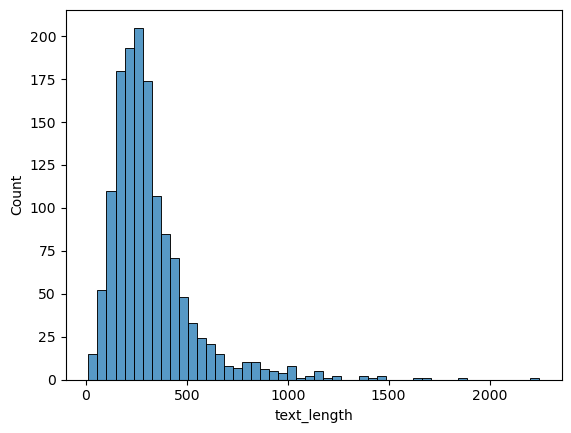

In [16]:
sns.histplot(df['text_length'], bins=50)
plt.show()

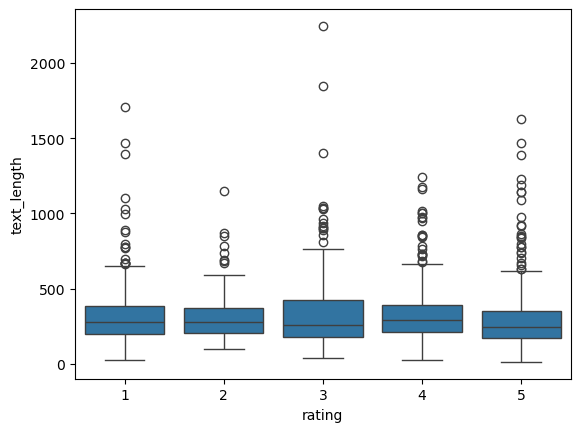

In [17]:
sns.boxplot(x='rating', y='text_length', data=df)
plt.show()

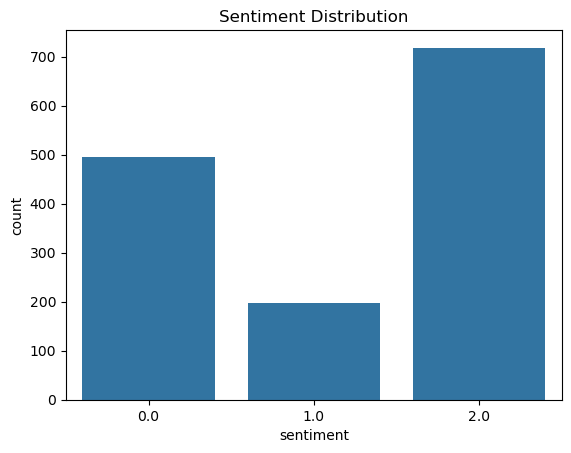

In [18]:
#sentiment mapping
def rating_to_sentiment(r):
    if r >= 4:
        return "2" #positive
    elif r == 3:
        return "1" #neutral
    else:
        return "0" #negative
    
df['sentiment'] = df['rating'].apply(rating_to_sentiment)
df['sentiment'] = df['sentiment'].astype(float)
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()


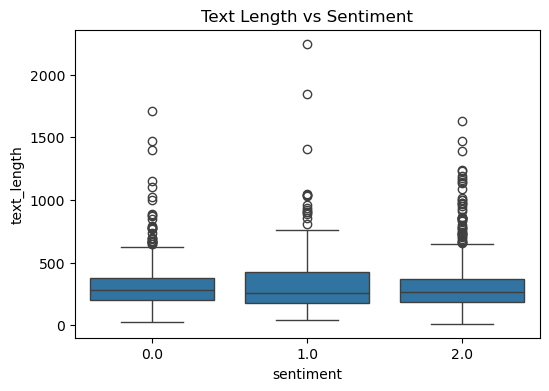

In [19]:
plt.figure(figsize=(6,4))
sns.boxplot(x='sentiment', y='text_length', data=df)
plt.title("Text Length vs Sentiment")
#plt.yscale("log")
plt.show()

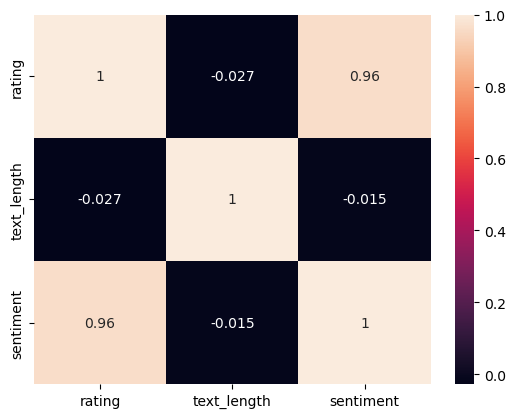

In [20]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

df_select = df[num_cols]

sns.heatmap(df_select.corr(), annot=True)
plt.show()

Rating and sentiment are strongly linked (by design).

Text length features are highly correlated with each other.

Text size alone does not determine sentiment.

Real predictive power will come from TF-IDF word features, not length features.

## **Vadar Sentiment Analysis**

In [21]:
#Vadar Sentiment Analysis
from nltk.sentiment import SentimentIntensityAnalyzer
import pandas as pd

sia = SentimentIntensityAnalyzer()

def get_vader_score(text):
    score = sia.polarity_scores(text)
    return score['compound']

df['vader_score'] = df['combine_text'].apply(get_vader_score)

In [22]:
def vader_label(score):
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"
    
df['vader_sentiment'] = df['vader_score'].apply(vader_label)

In [23]:
label_mapping = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

df["vader_sentiment_num"] = df["vader_sentiment"].map(label_mapping)

In [24]:
from sklearn.metrics import accuracy_score, classification_report

print('Accuracy:', accuracy_score(df['sentiment'], df['vader_sentiment_num']))
print('\nClassification Report:\n')
print(classification_report(df['sentiment'], df['vader_sentiment_num']))

Accuracy: 0.7228915662650602

Classification Report:

              precision    recall  f1-score   support

         0.0       0.74      0.71      0.73       496
         1.0       0.15      0.03      0.04       197
         2.0       0.73      0.92      0.82       718

    accuracy                           0.72      1411
   macro avg       0.54      0.55      0.53      1411
weighted avg       0.66      0.72      0.68      1411



## **Stopwords**

In [25]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

stop_words.discard("not")
stop_words.discard("no")
stop_words.discard("never")

In [26]:
df = df.drop(columns=['combine_text', 'language'])

In [27]:
# Prepare dataset for modeling
X = df['cleaned_text']
y = df['sentiment']

## **Train-Test Split**

In [28]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## **TF-IDF Feature Extraction**

In [29]:
#TF-IDF Features
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(ngram_range=(1,2), max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [30]:
TfidfVectorizer(ngram_range=(1,2))

TfidfVectorizer(ngram_range=(1, 2))

In [31]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, class_weight="balanced")
lr.fit(X_train_tfidf, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [32]:
# Multinomial Naive Bayes
from sklearn.naive_bayes import MultinomialNB
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

MultinomialNB()

In [33]:
from sklearn.svm import LinearSVC

svc = LinearSVC(class_weight="balanced")
svc.fit(X_train_tfidf, y_train)

LinearSVC(class_weight='balanced')

In [34]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train_tfidf, y_train)

RandomForestClassifier()

In [35]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
gb.fit(X_train_tfidf, y_train)

GradientBoostingClassifier()

In [36]:
from sklearn.metrics import accuracy_score

def evaluate(model, name):
    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy:", acc)

In [37]:
# ensure y_pred exists by predicting on the test set
y_pred = svc.predict(X_test_tfidf)

print(y_test.value_counts())
print(pd.Series(y_pred, name="y_pred").value_counts())

sentiment
2.0    144
0.0     99
1.0     40
Name: count, dtype: int64
y_pred
2.0    154
0.0    107
1.0     22
Name: count, dtype: int64


In [38]:
evaluate(lr, "Logistic Regression")
evaluate(nb, "Naive Bayes")
evaluate(svc, "SVM")
evaluate(rf, "Random Forest")
evaluate(gb, "Gradient Boosting")

Logistic Regression Accuracy: 0.7915194346289752
Naive Bayes Accuracy: 0.7314487632508834
SVM Accuracy: 0.8056537102473498
Random Forest Accuracy: 0.7773851590106007
Gradient Boosting Accuracy: 0.7915194346289752


In [39]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.78      0.84      0.81        99
         1.0       0.45      0.25      0.32        40
         2.0       0.88      0.94      0.91       144

    accuracy                           0.81       283
   macro avg       0.70      0.68      0.68       283
weighted avg       0.78      0.81      0.79       283



## **Confusion Matrix**

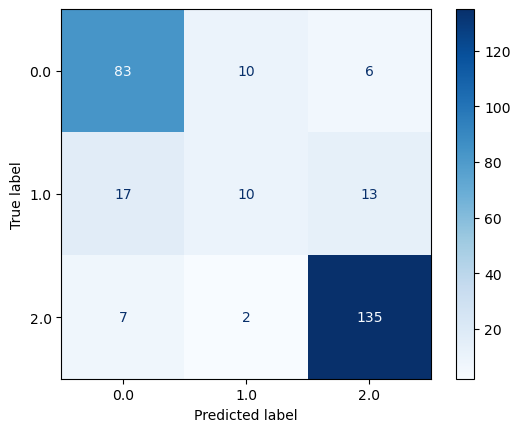

In [40]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues", colorbar=True)
plt.show()

In [41]:
import pickle

pickle.dump(vectorizer, open("tfidf_vectorizer.pkl", "wb"))

pickle.dump(svc, open("sentiment_model.pkl", "wb"))

In [42]:
# SVM predictions
y_pred_svc = svc.predict(X_test_tfidf)

In [43]:
from sklearn.metrics import classification_report

print("SVM Model")
print(classification_report(y_test, y_pred_svc))


SVM Model
              precision    recall  f1-score   support

         0.0       0.78      0.84      0.81        99
         1.0       0.45      0.25      0.32        40
         2.0       0.88      0.94      0.91       144

    accuracy                           0.81       283
   macro avg       0.70      0.68      0.68       283
weighted avg       0.78      0.81      0.79       283



In [47]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()
print(analyzer.polarity_scores("This is amazing"))

{'neg': 0.0, 'neu': 0.345, 'pos': 0.655, 'compound': 0.5859}


In [ ]:
#pip install vaderSentiment


  Using cached vaderSentiment-3.3.2-py2.py3-none-any.whl.metadata (572 bytes)
Using cached vaderSentiment-3.3.2-py2.py3-none-any.whl (125 kB)


In [46]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()
print(analyzer.polarity_scores("This is amazing"))

{'neg': 0.0, 'neu': 0.345, 'pos': 0.655, 'compound': 0.5859}
